In [1]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

import numpy as np
import pandas as pd
from gryffin import Gryffin

import matplotlib.pyplot as plt
import matplotlib
%matplotlib inline

import seaborn as sns
sns.set(context='talk', style='ticks')

In [2]:
def objective(x):

    def sigmoid(x, l, k, x0):
        return l / (1 + np.exp(-k*(x-x0)))

    sigs = [sigmoid(x, -1, 40, 0.2),
            sigmoid(x,  1, 40, 0.4),
            sigmoid(x,  -0.7, 50, 0.6),
            sigmoid(x, 0.7, 50, 0.9)
           ]

    return np.sum(sigs, axis=0) + 1

def compute_objective(param):
    x = param['x']
    param['obj'] = objective(x)
    return param

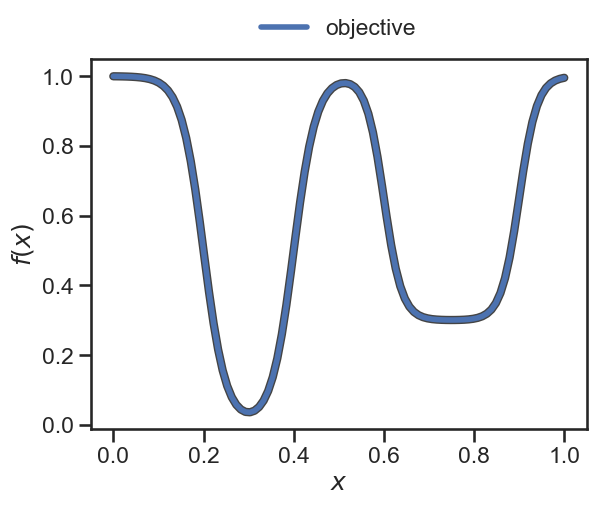

In [3]:
x = np.linspace(0, 1, 100)
_ = plt.plot(x, objective(x), linewidth=6, color='#444444')
_ = plt.plot(x, objective(x), linewidth=4, label='objective')
_ = plt.xlabel('$x$')
_ = plt.ylabel('$f(x)$')
_ = plt.legend(loc='lower center', ncol=2, bbox_to_anchor=(0.5 ,1.), frameon=False)

In [4]:
config = {
    "parameters": [
        {"name": "x", "type": "continuous", "low": 0., "high": 1., "size": 1}
    ],
    "objectives": [
        {"name": "obj", "goal": "min"}
    ]
}

In [5]:
gryffin = Gryffin(config_dict=config, silent=True)

In [6]:
%debug

observations = []
MAX_ITER = 15

for num_iter in range(MAX_ITER):
    print('-'*20, 'Iteration:', num_iter+1, '-'*20)

    # Query for new parameters
    params = gryffin.recommend(observations=observations)

    # Params is a list of dict, where each dict containts the proposed parameter values, e.g., {'x':0.5}
    # in this example, len(params) == 1 and we select the single set of parameters proposed
    param = params[0]
    print('  Proposed Parameters:', param, end=' ')

    # Evaluate the proposed parameters. "compute_objective" takes param, which is a dict, and adds the key "obj" with the
    # objective function value
    observation = compute_objective(param)
    print('==> :', observation['obj'])

    # Append this observation to the previous experiments
    observations.append(observation)

ERROR:root:No traceback has been produced, nothing to debug.


-------------------- Iteration: 1 --------------------


Could not find any observations, falling back to random sampling

  Proposed Parameters: {'x': np.float32(0.2190843)} ==> : 0.3186339
-------------------- Iteration: 2 --------------------


AttributeError: module 'numpy' has no attribute 'float'.
`np.float` was a deprecated alias for the builtin `float`. To avoid this error in existing code, use `float` by itself. Doing this will not modify any behavior and is safe. If you specifically wanted the numpy scalar type, use `np.float64` here.
The aliases was originally deprecated in NumPy 1.20; for more details and guidance see the original release note at:
    https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations

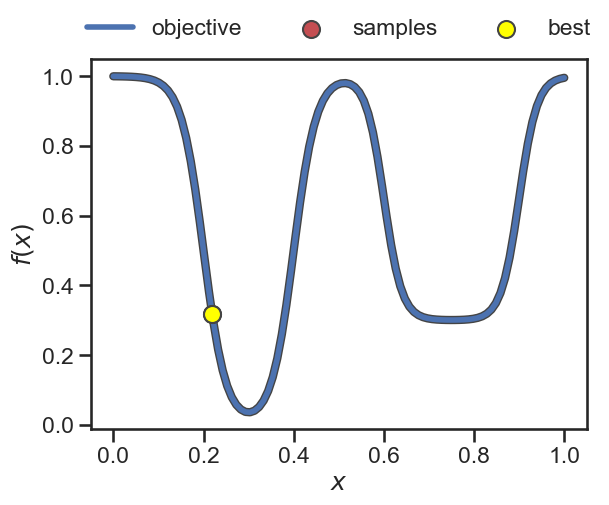

In [8]:
# objective function
x = np.linspace(0, 1, 100)
y = [objective(x_i) for x_i in x]

# observed parameters and objectives
samples_x = [obs['x'] for obs in observations]
samples_y = [obs['obj'] for obs in observations]

_ = plt.plot(x, y, linewidth=6, color='#444444')
_ = plt.plot(x, y, linewidth=4, label='objective')

_ = plt.scatter(samples_x, samples_y, zorder=10, s=150, color='r', edgecolor='#444444', label='samples')

# highlight best
_ = plt.scatter(samples_x[np.argmin(samples_y)], np.min(samples_y), zorder=11, s=150,
                color='yellow', edgecolor='#444444', label='best')

# labels
_ = plt.xlabel('$x$')
_ = plt.ylabel('$f(x)$')
_ = plt.legend(loc='lower center', ncol=3, bbox_to_anchor=(0.5 ,1.), frameon=False)